## Object Detector
### RF-DETR

*Daniela Curmi, 0058805L*

In [1]:
# All libraries used for this notebook have been included below
import os
import json
import torch
from rfdetr import RFDETRNano
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import random
from pathlib import Path
import cv2
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Prepare COCO-based_COCO Dataset structure

In [ ]:
# Dataset Path 
ROOT = r"Individual Results/RF-DETR/COCO-based_COCO"
splits = ["train", "val", "test"]

for split in splits:
    ann_file = os.path.join(ROOT, split, "_annotations.coco.json")
    
    # Load JSON
    with open(ann_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Add supercategory if missing
    for category in data.get("categories", []):
        if "supercategory" not in category:
            category["supercategory"] = "sign"  

    # Save back
    with open(ann_file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

    print(f"Updated {ann_file} with supercategory.")

Updated COCO-based_COCO\train\_annotations.coco.json with supercategory.
Updated COCO-based_COCO\val\_annotations.coco.json with supercategory.
Updated COCO-based_COCO\test\_annotations.coco.json with supercategory.


### Define RF-DETR Model

In [ ]:
# Define RF-DETR nano model
model = RFDETRNano(num_classes=6, pretrained=False, device=device)

rf-detr-nano.pth: 100%|██████████| 349M/349M [00:11<00:00, 31.6MiB/s] 


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


### RF-DETR Object Detector Training Loop

In [ ]:
# Train the RF-DETR nano model
model.train(
    dataset_dir="Individual Results/RF-DETR/COCO-based_COCO",
    epochs=100,
    batch_size=4,
    lr=2e-4,
    weight_decay=1e-4,
    warmup_epochs=5,
    patience=20,          
    device=device
)

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=6, grad_accum_steps=4, amp=True, lr=0.0002, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_loa

Epoch: [0]  [ 0/27]  eta: 0:13:34  lr: 0.000001  class_error: 100.00  loss: 14.3550 (14.3550)  loss_ce: 3.1797 (3.1797)  loss_bbox: 0.9695 (0.9695)  loss_giou: 0.8408 (0.8408)  loss_ce_0: 3.0709 (3.0709)  loss_bbox_0: 0.9864 (0.9864)  loss_giou_0: 0.8180 (0.8180)  loss_ce_enc: 2.4430 (2.4430)  loss_bbox_enc: 1.1293 (1.1293)  loss_giou_enc: 0.9176 (0.9176)  loss_ce_unscaled: 3.1797 (3.1797)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.1939 (0.1939)  loss_giou_unscaled: 0.4204 (0.4204)  cardinality_error_unscaled: 3898.7500 (3898.7500)  loss_ce_0_unscaled: 3.0709 (3.0709)  loss_bbox_0_unscaled: 0.1973 (0.1973)  loss_giou_0_unscaled: 0.4090 (0.4090)  cardinality_error_0_unscaled: 3898.7500 (3898.7500)  loss_ce_enc_unscaled: 2.4430 (2.4430)  loss_bbox_enc_unscaled: 0.2259 (0.2259)  loss_giou_enc_unscaled: 0.4588 (0.4588)  cardinality_error_enc_unscaled: 3898.7500 (3898.7500)  time: 30.1773  data: 25.7364  max mem: 2103
Epoch: [0]  [10/27]  eta: 0:01:05  lr: 0.000016  c

Test:  [ 0/25]  eta: 0:05:01  class_error: 100.00  loss: 6.3576 (6.3576)  loss_ce: 1.3750 (1.3750)  loss_bbox: 0.2007 (0.2007)  loss_giou: 0.3841 (0.3841)  loss_ce_0: 1.7578 (1.7578)  loss_bbox_0: 0.1234 (0.1234)  loss_giou_0: 0.3862 (0.3862)  loss_ce_enc: 1.5547 (1.5547)  loss_bbox_enc: 0.1546 (0.1546)  loss_giou_enc: 0.4213 (0.4213)  loss_ce_unscaled: 1.3750 (1.3750)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.0401 (0.0401)  loss_giou_unscaled: 0.1921 (0.1921)  cardinality_error_unscaled: 299.0000 (299.0000)  loss_ce_0_unscaled: 1.7578 (1.7578)  loss_bbox_0_unscaled: 0.0247 (0.0247)  loss_giou_0_unscaled: 0.1931 (0.1931)  cardinality_error_0_unscaled: 299.0000 (299.0000)  loss_ce_enc_unscaled: 1.5547 (1.5547)  loss_bbox_enc_unscaled: 0.0309 (0.0309)  loss_giou_enc_unscaled: 0.2107 (0.2107)  cardinality_error_enc_unscaled: 299.0000 (299.0000)  time: 12.0498  data: 11.7501  max mem: 2888
Test:  [10/25]  eta: 0:00:18  class_error: 100.00  loss: 5.7327 (6.6145)  los

### Individual Analysis

In [ ]:
# Load test images and annotations
test_images_dir = Path("Individual Results/RF-DETR/COCO-based_COCO/test/")
ann_file = "Individual Results/RF-DETR/COCO-based_COCO/test/_annotations.coco.json"

class_names = [
    "Blind-Spot Mirror (Convex)",
    "No Entry (One Way)",
    "No Through Road (T-Sign)",
    "Pedestrian Crossing",
    "Roundabout Ahead",
    "Stop"
]

# Load models' best checkpoint
model = RFDETRNano(num_classes=6, pretrained=False, pretrain_weights="Individual Results/RF-DETR/output/checkpoint_best_total.pth", device=device)

# Store test images and coco annotations
image_paths = sorted(str(p) for p in test_images_dir.glob("*.jpg"))
coco = COCO(ann_file)

for cat in coco.loadCats(coco.getCatIds()):
    print(f"COCO category ID: {cat['id']}, name: {cat['name']}")

class_id_to_name = {idx: name for idx, name in enumerate(class_names)}

# Model predictions
detections_list = model.predict(images=image_paths, conf_threshold=0.25, iou_threshold=0.5)


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
COCO category ID: 1, name: Blind-Spot Mirror (Convex)
COCO category ID: 2, name: No Entry (One Way)
COCO category ID: 3, name: No Through Road (T-Sign)
COCO category ID: 4, name: Pedestrian Crossing
COCO category ID: 5, name: Roundabout Ahead
COCO category ID: 6, name: Stop


### Sample Sign Object Detection RF-DETR

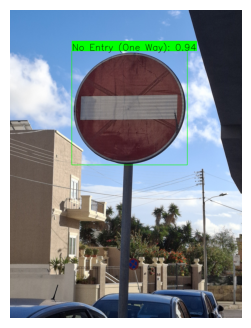

In [ ]:
# Sample detection visualisation
def visualize_detections(image_path, detections, class_id_to_name):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = detections.xyxy
    scores = detections.confidence
    labels = detections.class_id

    BOX_THICKNESS = 6
    FONT_SCALE = 4
    TEXT_THICKNESS = 4

    for box, score, label in zip(boxes, scores, labels):
        label = int(label) - 1  # shift by 1 to match coco category id and model id

        # Skip invalid predictions
        if label not in class_id_to_name:
            continue

        x1, y1, x2, y2 = map(int, box)
        class_name = class_id_to_name[label]
        text = f"{class_name}: {score:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), thickness=BOX_THICKNESS)
        (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, TEXT_THICKNESS)
        cv2.rectangle(img, (x1, y1 - text_h - baseline - 8), (x1 + text_w + 6, y1), (0, 255, 0), thickness=-1)
        cv2.putText(img, text, (x1 + 3, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 0, 0),
                    thickness=TEXT_THICKNESS, lineType=cv2.LINE_AA)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

for img_path, detections in zip(image_paths, detections_list):
    visualize_detections(img_path, detections, class_id_to_name)
    break

### Side-by-Side Ground Truth and Predictions

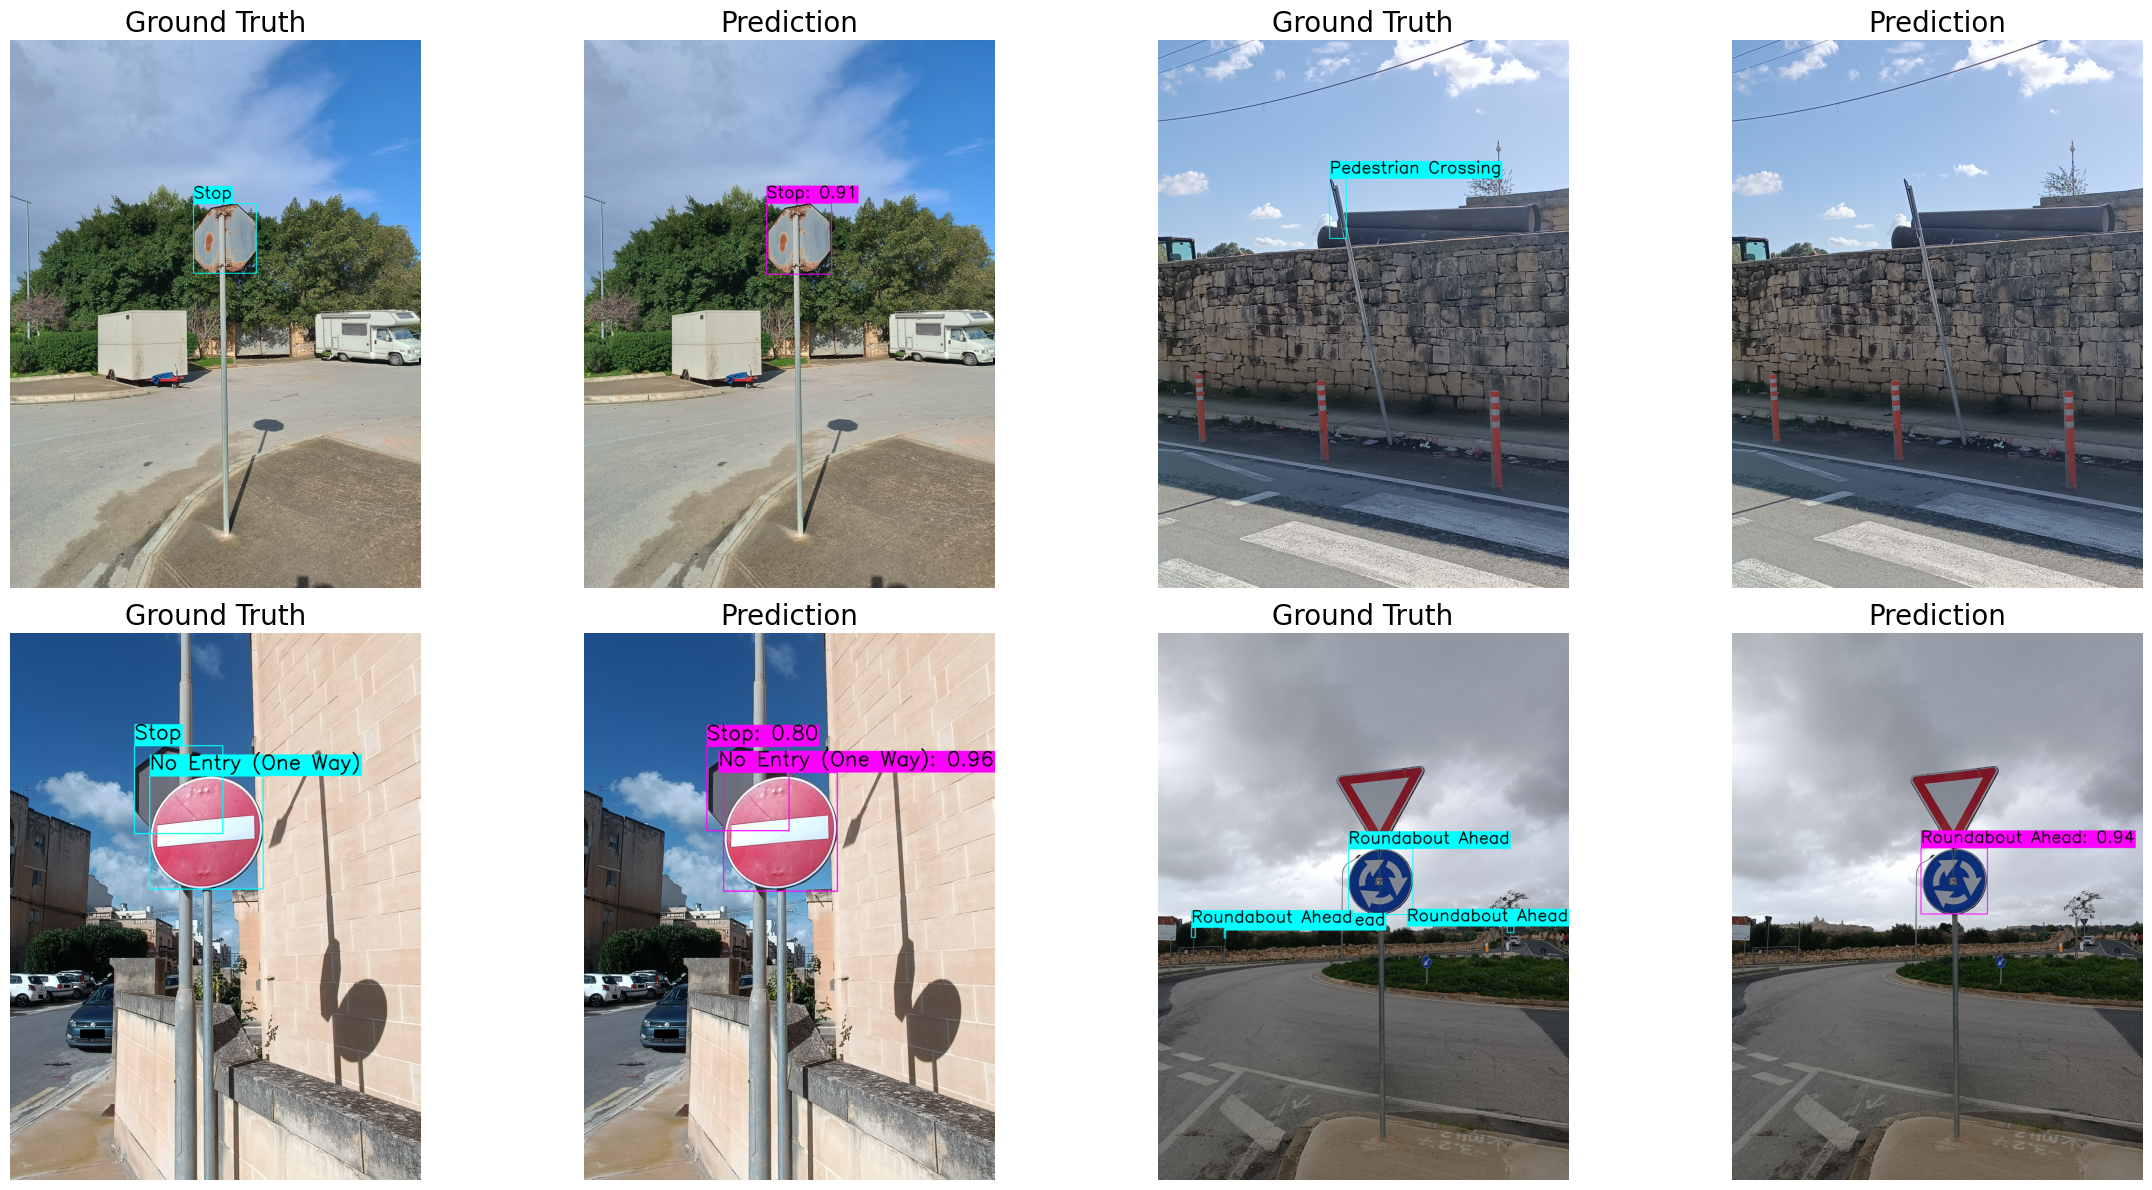

In [ ]:
def draw_boxes(img, boxes, labels, class_names, scores=None, color=(0, 255, 0)):
    BOX_THICKNESS = 6
    FONT_SCALE = 4
    TEXT_THICKNESS = 7

    img_h, img_w = img.shape[:2]

    for i, box in enumerate(boxes):
        label = labels[i]

        if label < 0 or label >= len(class_names):
            continue

        x1, y1, x2, y2 = map(int, box)
        text = class_names[label]

        if scores is not None:
            text += f": {scores[i]:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, BOX_THICKNESS)
        (tw, th), bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, TEXT_THICKNESS)

        # Text positioning and background rectangle
        tx = x1
        ty = y1  

        if tx + tw > img_w:
            tx = img_w - tw
        tx = max(tx, 0)

        if y1 - th - bl < 0:
            ty = y1 + th + bl

        cv2.rectangle(img, (tx, ty - th - bl), (tx + tw, ty), color, -1)
        cv2.putText(img, text, (tx, ty - bl), cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 0, 0), TEXT_THICKNESS, cv2.LINE_AA)

def get_ground_truth(coco, image_path, class_names):
    file_name = Path(image_path).name

    # Get COCO image ID
    img_id = next(
        img["id"] for img in coco.imgs.values()
        if img["file_name"] == file_name
    )

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

    boxes = []
    labels = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        boxes.append([x, y, x + w, y + h])
        labels.append(ann["category_id"] - 1) # shift by 1 to match coco category id and model id

    return boxes, labels

# Plot 4 random pairs of ground truths and predictions
indices = random.sample(range(len(image_paths)), 4)

plt.figure(figsize=(24, 12))

for i, idx in enumerate(indices):
    img_path = image_paths[idx]
    dets = detections_list[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ground truth
    img_gt = img.copy()
    gt_boxes, gt_labels = get_ground_truth(coco, img_path, class_names)

    draw_boxes(img_gt, gt_boxes, gt_labels, class_names=class_names, color=(0, 255, 255))

    # Predictions
    img_pred = img.copy()

    pred_boxes = dets.xyxy
    pred_scores = dets.confidence
    pred_labels = [int(c) - 1 for c in dets.class_id]  # shift by 1 to match coco category id and model id

    draw_boxes(img_pred, pred_boxes, pred_labels, class_names=class_names, scores=pred_scores, color=(255, 0, 255))

    # Plot 2 rows with 2 pairs of GT and Preds
    row = i // 2
    col = (i % 2) * 2

    plt.subplot(2, 4, row * 4 + col + 1)
    plt.imshow(img_gt)
    plt.title("Ground Truth", fontsize=20)
    plt.axis("off")

    plt.subplot(2, 4, row * 4 + col + 2)
    plt.imshow(img_pred)
    plt.title("Prediction", fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

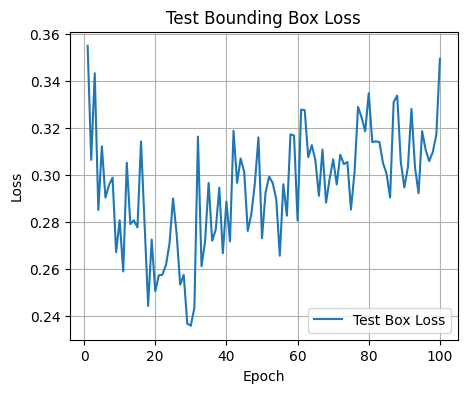

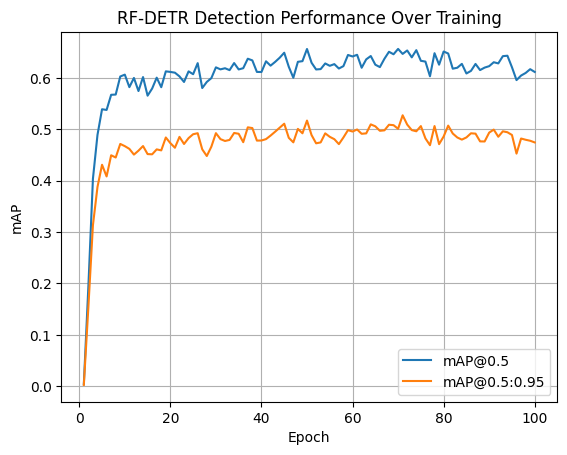

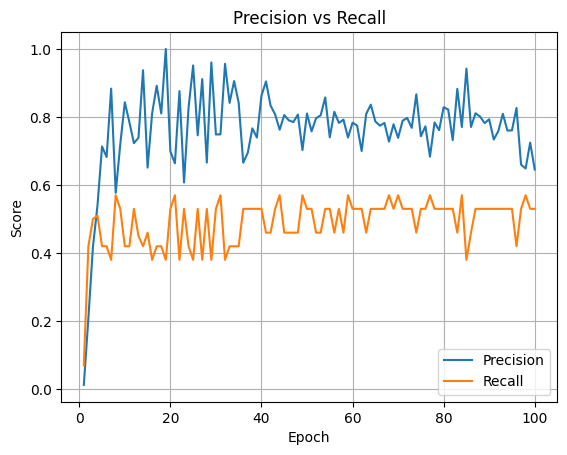

In [ ]:
# Path to your logs.txt
log_file = "Individual Results/RF-DETR/output/log.txt"

# Read per-epoch logs
test_bbox_loss = []
map_05 = []
map_05_95 = []
precision = []
recall = []

with open(log_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # Each line is a JSON object
        data = json.loads(line)
        
        # Test bounding box loss
        test_bbox_loss.append(data.get("test_loss_bbox", 0.0))
        
        # Test results per epoch (overall 'all' class)
        test_results = data.get("test_results_json", {})
        all_class = None
        for c in test_results.get("class_map", []):
            if c["class"] == "all":
                all_class = c
                break
        
        if all_class:
            map_05_95.append(all_class.get("map@50:95", 0.0))
            map_05.append(all_class.get("map@50", 0.0))
            precision.append(all_class.get("precision", 0.0))
            recall.append(all_class.get("recall", 0.0))
        else:
            # fallback
            map_05_95.append(0.0)
            map_05.append(0.0)
            precision.append(0.0)
            recall.append(0.0)

epochs = range(1, len(test_bbox_loss) + 1)

plt.figure(figsize=(5,4))
# Test Bounding Box Loss
plt.plot(epochs, test_bbox_loss, label="Test Box Loss")
plt.title("Test Bounding Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

# mAP@0.5 and mAP@0.5:0.95
plt.plot(epochs, map_05, label="mAP@0.5")
plt.plot(epochs, map_05_95, label="mAP@0.5:0.95")
plt.title("RF-DETR Detection Performance Over Training")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.grid()
plt.legend()
plt.show()

# Precision vs Recall
plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.title("Precision vs Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.grid()
plt.legend()
plt.show()


### Group Analysis

In [2]:
# Load the results.json file
with open("Individual Results/RF-DETR/output/results.json", "r") as f:
    results = json.load(f)

# Choose which split to use: 'test' or 'valid'
split = "test"
class_metrics = results["class_map"][split]

all_metrics = next(
    m for m in class_metrics if m["class"] == "all"
)

map_50 = all_metrics["map@50"]
map_50_95 = all_metrics["map@50:95"]
precision = all_metrics["precision"]
recall = all_metrics["recall"]

# Print overall metrics
metrics = {
    "Model Name": "RF-DETR Nano",
    "mAP@0.5": map_50,
    "mAP@0.5:0.95": map_50_95,
    "Precision": precision,
    "Recall": recall
}

# Convert to DataFrame and save to CSV
df = pd.DataFrame([metrics])
df.to_csv("Group Results/Detector/rfdetr.csv", index=False)

print("Overall Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Print per-class metrics
print("\nPer-class metrics:")
for cls in class_metrics:
    print(f"{cls['class']}: mAP@50: {cls['map@50']:.3f}, "
          f"mAP@50:95: {cls['map@50:95']:.3f}, "
          f"Precision: {cls['precision']:.3f}, Recall: {cls['recall']:.3f}")


Overall Metrics:
Model Name: RF-DETR Nano
mAP@0.5: 0.6972
mAP@0.5:0.95: 0.5620
Precision: 0.8770
Recall: 0.5500

Per-class metrics:
Blind-Spot Mirror (Convex): mAP@50: 0.864, mAP@50:95: 0.783, Precision: 1.000, Recall: 0.550
No Entry (One Way): mAP@50: 0.760, mAP@50:95: 0.595, Precision: 0.905, Recall: 0.550
No Through Road (T-Sign): mAP@50: 0.755, mAP@50:95: 0.600, Precision: 1.000, Recall: 0.550
Pedestrian Crossing: mAP@50: 0.497, mAP@50:95: 0.359, Precision: 0.588, Recall: 0.550
Roundabout Ahead: mAP@50: 0.541, mAP@50:95: 0.461, Precision: 0.769, Recall: 0.550
Stop: mAP@50: 0.766, mAP@50:95: 0.573, Precision: 1.000, Recall: 0.550
all: mAP@50: 0.697, mAP@50:95: 0.562, Precision: 0.877, Recall: 0.550
